# Objective:

1. Determine land eligibility for photovoltaic (PV) modules in the <a href="https://en.wikipedia.org/wiki/Aachen_(district)">Aachen administration region</a> considering that...
    1. PV modules should not cover agricultural areas (because people need to eat)
    2. PV modules should not be within 200 meters of a major road way (because they may get dirty)
    3. PV modules should not be within 1000 meters of a settlement area (because they are too shiny)

2. Save the resulting available lands to a raster (.tif) file


## Given that:

1. **aachenRegion** is a path to a vector file describing the study region
2. **clcRaster** is a path to a local copy of the <a href="http://land.copernicus.eu/pan-european/corine-land-cover/clc-2012/view">Corine Land Cover</a> dataset
3. **roadways** is a path to a vector file which describes the path of all roadways in the study area
    - Each feature in the roadways vector also has attribute named 'type' distinguishing the class of the that specific route (for example: motorway, primary, secondary, residential, service, ect...)

In [1]:
# Import GLAES
import glaes as gl
import matplotlib.pyplot as plt
from pathlib import Path

/fast/home/l-madeisky/.conda/envs/glaes_2026/lib/python3.13/site-packages/geokit/core/raster.py:19: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.3)
  from scipy.interpolate import RectBivariateSpline


# 1. An *ExclusionCalculator* object is initialized

The Aachen region will be the study area

The [EPSG:3035](http://spatialreference.org/ref/epsg/etrs89-etrs-laea/) spatial reference system is used, since it describes relational distances in meters over the entire study area

An inherent resolution of 100 x 100 meters is chosen as this is small enough to capture small details, but not so large as to require too many resources


<Axes: >

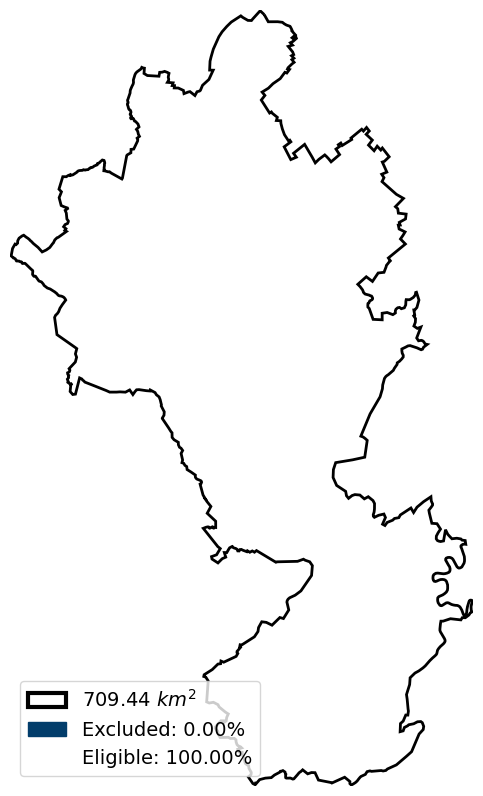

In [2]:
# Choose a region to operate on (Here, a predefined region for Aachen, Germany is used)
regionPath = gl._test_data_["aachenShapefile.shp"]

# Initialize ExclusionCalculator object
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)
# Visualize
ec.draw()

## exclude the normal way

Memory usage during calc: 260.734375 MB


<Axes: >

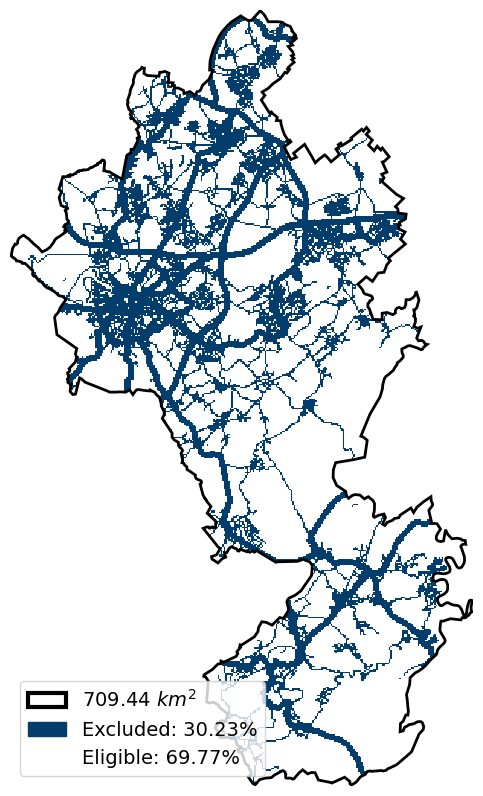

In [21]:
# Set a path to a local copy of the OSM roads dataset (Here, a small sample is provided around Aachen)
roadwaysPath = gl._test_data_["aachenRoads.shp"]

# Apply Exclusion
ec.excludeVectorType(
    gl._test_data_["aachenRoads.shp"],
    buffer=200,
    where="maxspeed='nan'"#OR type='primary' OR type='trunk'",
)

# Visualize
ec.draw()

# prior new

## create prior

In [ ]:
from create_priors_0 import evaluate_area_by_proximity

In [ ]:
# todo create prior from roads shape within aachen with buffer 200

In [ ]:
#apply prior 

In [25]:
#check vs the two other results

## severin: apply prior for exclusion

In [22]:
priorSample = gl._test_data_["roads_prior_clip.tif"]
prior = gl.core.priors.PriorSource(priorSample)

In [23]:
ec_p = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

ec_p.excludePrior(prior, value=(0, 200))

Memory usage during calc: 263.31640625 MB


<Axes: >

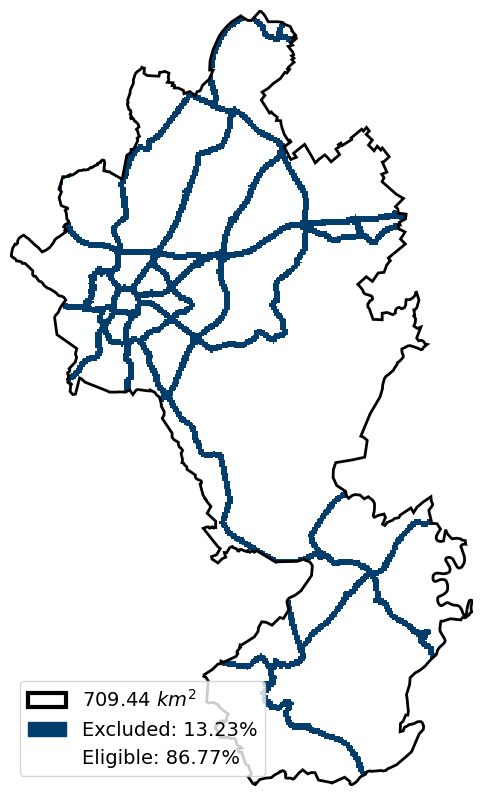

In [24]:
ec_p.draw()

### TODO

1. create prior
2. exclude prior
3. same results ?

In [ ]:
base_path = Path.cwd().resolve().parents[0]
base_path

In [76]:
from glaes.deletme_create_prior.create_priors_0 import evaluate_area_by_proximity


ModuleNotFoundError: No module named 'glaes.deletme_create_prior'

---

### plotting for comparison

load raster and plot

In [ ]:
import geokit as gk
gk.drawRaster(priorSample)
gk.raster.rasterInfo(priorSample)


load shape and plot

In [ ]:
aachen_path = gl._test_data_["aachenShapefile.shp"]
aachen= gk.vector.extractFeatures(aachen_path, srs=3035)

In [ ]:
gk.drawGeoms(aachen,   figsize=(5, 5), srs=3035)

In [ ]:

aachen_roads = gk.vector.extractFeatures(roadwaysPath)
gk.drawGeoms(aachen_roads,   figsize=(5, 5), srs=3035)

load shape as mask and raster as mask

In [ ]:
aachen_rm = gk.RegionMask.load(
    region=aachen_path,
    pixelRes=20,
    srs=3035,
)

In [ ]:
ras = aachen_rm.warp(
    source = priorSample,
    returnMatrix=False,
)

In [ ]:
gk.drawRaster(ras, figsize=(6, 6))

load shape as mask and shape with mask

In [ ]:
aachen_roads_0 = aachen_rm.extractFeatures(
    source = roadwaysPath)

aachen_roads_0.head()

In [ ]:
axh = aachen_rm.drawGeoms(aachen_roads_0, figsize=(5, 6), hideAxis=True, color="b")
plt.show()